In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib import cm

Plot the spatial maps of impervious fraction for Default, LCZ, WSF-MB, and Geoscape - Figure 2

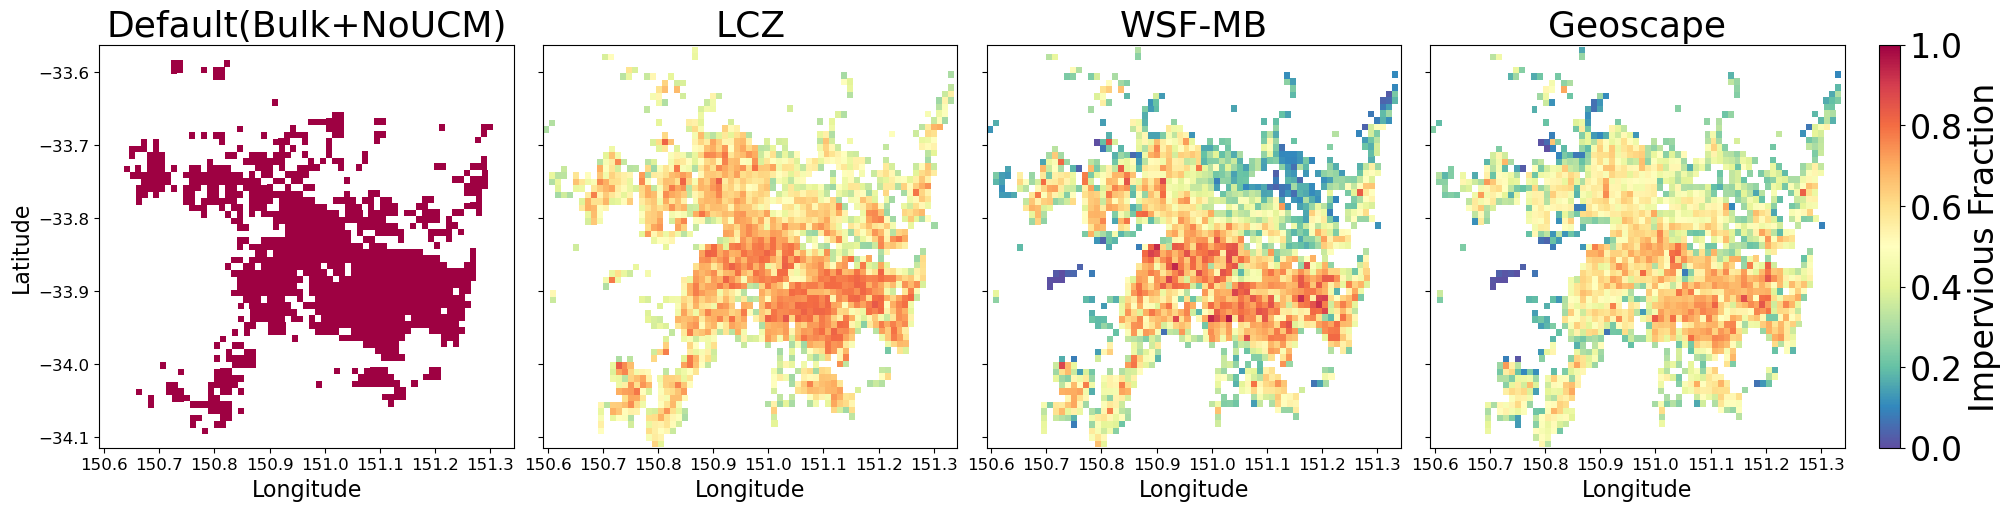

In [ ]:
# File paths and labels
files = {
    "Default(Bulk+NoUCM)": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/bulk_urban.nc",
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/LCZ_urban.nc",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/WSF3DMSB_urban.nc",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/Geoscape_urban.nc"
}

# Get domain limits from one of the standard-domain files
ref_ds = xr.open_dataset(files["LCZ"])
lat_min = ref_ds["XLAT"].min().item()
lat_max = ref_ds["XLAT"].max().item()
lon_min = ref_ds["XLONG"].min().item()
lon_max = ref_ds["XLONG"].max().item()

# Plot setup
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20, 5), constrained_layout=True)

for i, (label, file_path) in enumerate(files.items()):
    ds = xr.open_dataset(file_path)
    lon = ds["XLONG"]
    lat = ds["XLAT"]
    urbfrac = ds["FRC_URB2D"]

    # Clip Bulk domain using slicing (no NaNs or masks)
    if label == "Default(Bulk+NoUCM)":
        mask = (
            (lat >= lat_min) & (lat <= lat_max) &
            (lon >= lon_min) & (lon <= lon_max)
        )
        urbfrac = urbfrac.where(mask, drop=True)
        lat = lat.where(mask, drop=True)
        lon = lon.where(mask, drop=True)

    ax = axs[i]
    pcm = ax.pcolormesh(lon, lat, urbfrac, shading="auto", cmap="Spectral_r", vmin=0, vmax=1)
    ax.set_title(f"{label}", fontsize=26)
    ax.set_xlabel("Longitude", fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=12)
    if i == 0:
        ax.set_ylabel("Latitude", fontsize=16)
    else:
        ax.set_yticklabels([])

# Shared colorbar
cbar = fig.colorbar(pcm, ax=axs, orientation="vertical", fraction=0.02, pad=0.02)
cbar.ax.tick_params(labelsize=24)
cbar.set_label("Impervious Fraction", fontsize=24)


plt.savefig("Imperv_fraction_comparison.png", dpi=300)
plt.show()


Plot probability density function (PDF) distribution of impervious fraction, plan area density, building surface to plan area ratio, and area-weighted mean building height for LCZ, WSF-MB, and Geoscape (and Default only for impervious fraction) - Figure 3

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
/scratch/pu02/mf9078/tmp/ipykernel_2861457/1662873439.py:86: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


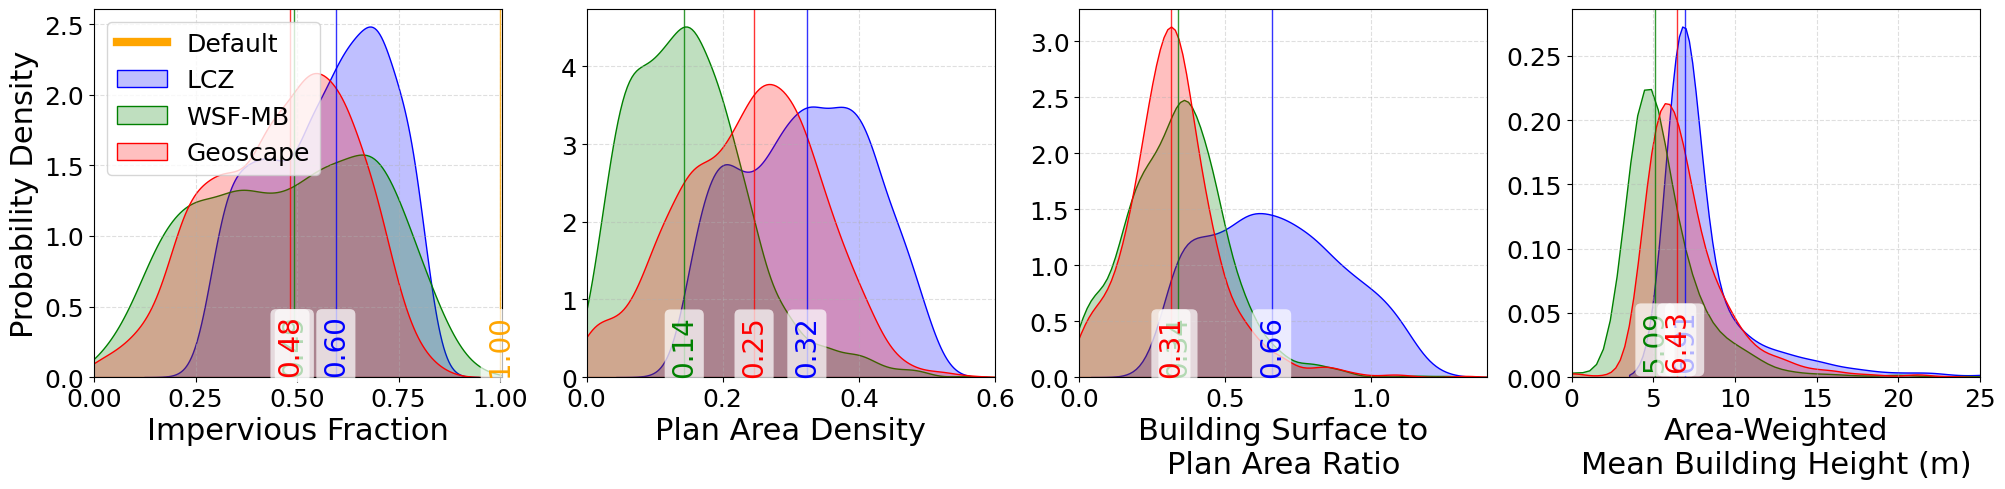

In [ ]:
# File paths and labels
files = {
    "Default": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/bulk_urban.nc", #(Bulk+NoUCM)
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/LCZ_urban.nc",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/WSF3DMSB_urban.nc",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/Geoscape_urban.nc"
}

# Colors assigned to each label
colors = {
    "Default": "orange", #(Bulk+NoUCM)
    "LCZ": "blue",
    "WSF-MB": "green",
    "Geoscape": "red"
}

# Variables to plot
variables = {
    "FRC_URB2D": {
        "label": "Impervious Fraction",
        "xlim": (0, 1.005)
    },
    "BUILD_AREA_FRACTION": {
        "label": "Plan Area Density",
        "xlim": (0, 0.6)
    },
    "BUILD_SURF_RATIO": {
        "label": "Building Surface to\nPlan Area Ratio",
        "xlim": (0, 1.4)
    },
    "BUILD_HEIGHT": {
        "label": "Area-Weighted\nMean Building Height (m)",
        "xlim": (0, 25)
    }
}

# Set up subplots
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20, 5), constrained_layout=True)

for i, (varname, props) in enumerate(variables.items()):
    ax = axs[i]
    
    for label, path in files.items():
        if varname == "FRC_URB2D" or path != "/g/data/fy29/mf9078/run_WRF/etamodified/plots/bulk_urban.nc":
            ds = xr.open_dataset(path)
            data = ds[varname].values.flatten()
            data = data[~np.isnan(data)]  # remove NaNs

            # Check if data has variation
            if len(np.unique(data)) > 1:
                sns.kdeplot(data, label=label, color=colors[label], fill=True, common_norm=False, ax=ax)
            else:
                # For constant data, manually add legend entry
                ax.plot([], [], color=colors[label], label=label, linewidth=6)  # Empty plot just for legend

            # Median line
            median_val = np.median(data)
            ax.axvline(median_val, color=colors[label], linestyle="-", linewidth=1, alpha=0.8)

            # Median label
            ax.text(
                median_val, 0.005, f"{median_val:.2f}",
                color=colors[label], ha="center", va="bottom", fontsize=20, rotation=90,  
                bbox=dict(boxstyle="round,pad=0.2", edgecolor='none', facecolor='white', alpha=0.7)
            )

    # Axis and layout
    ax.set_xlim(*props["xlim"])
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.set_xlabel(props["label"], fontsize=22)
    ax.set_ylabel("")
    ax.grid(True, linestyle="--", alpha=0.4)
    

# Add legend to the top subplot
axs[0].set_ylabel("Probability Density", fontsize=22)
axs[0].legend(loc="upper left", fontsize=18)
# Remove the current legend line and add this before plt.tight_layout():
plt.tight_layout()
plt.savefig("PDF_urban_variables_1x4.png", dpi=300)
plt.show()


Plot spatial maps of plan area density, building surface to plan area ratio, and area-weighted mean building height for LCZ, WSF-MB, and Geoscape - Figure S1

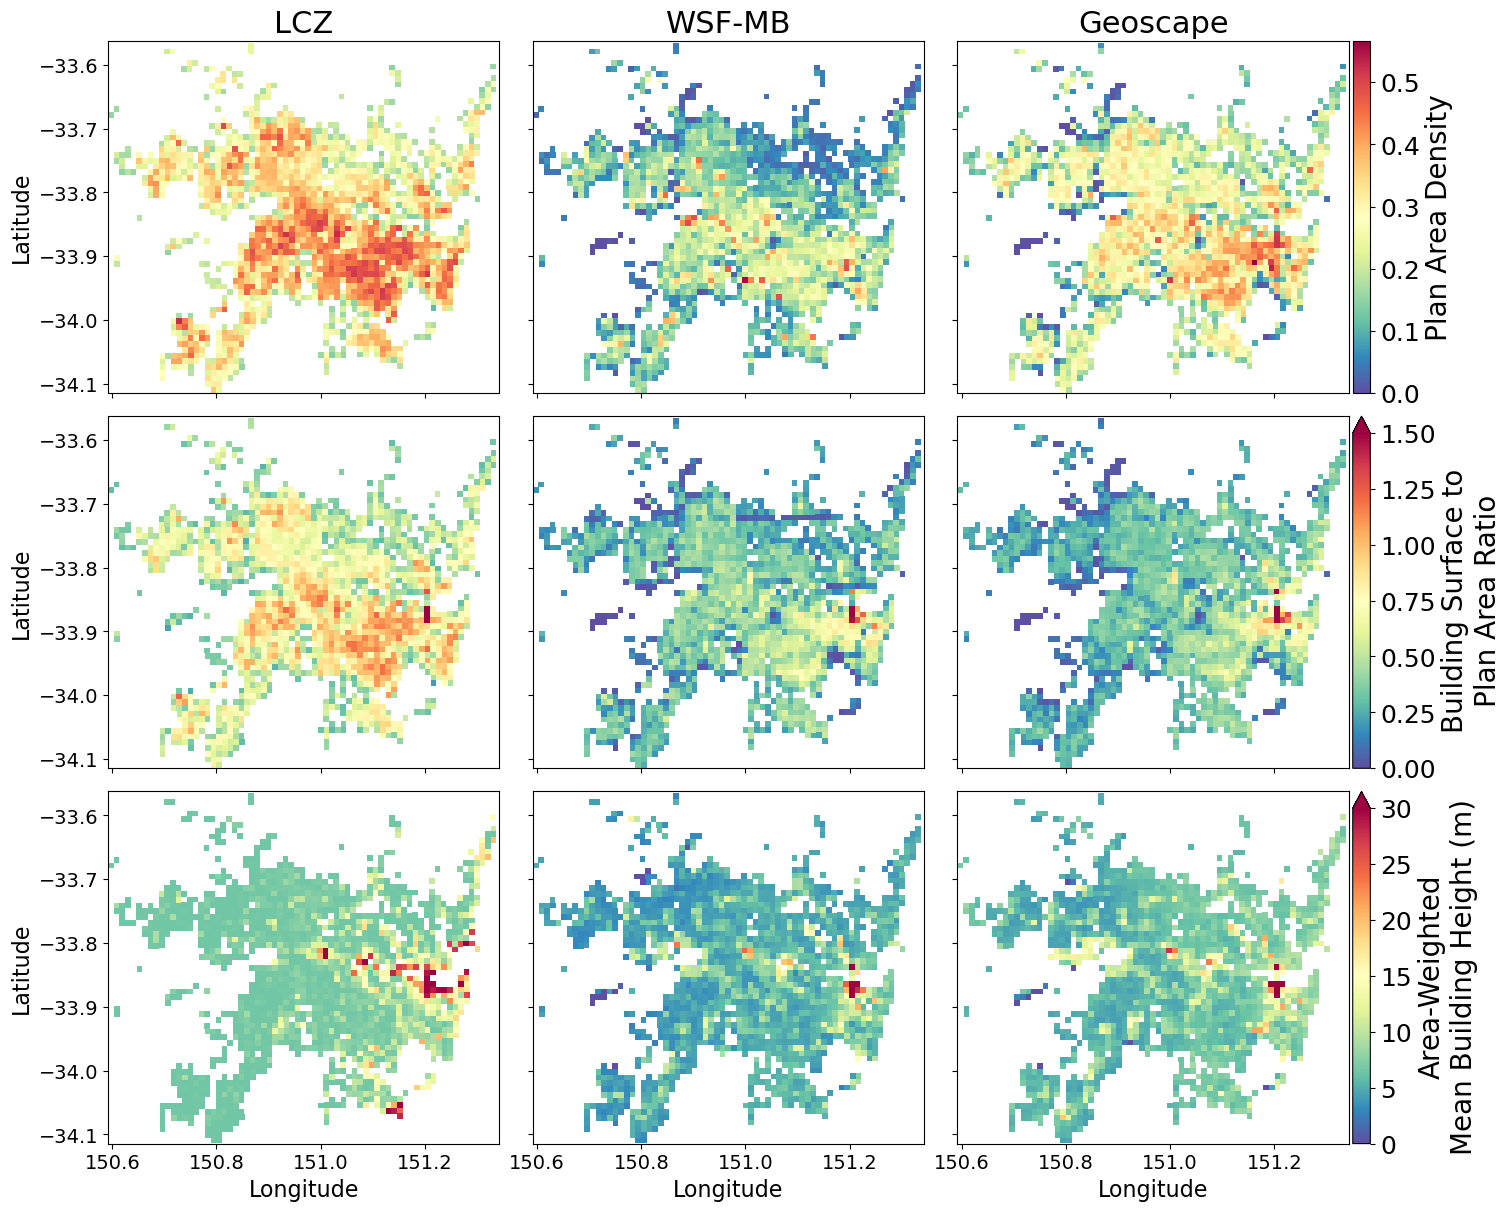

In [ ]:
# File paths and labels
files = {
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/LCZ_urban.nc",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/WSF3DMSB_urban.nc",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/Geoscape_urban.nc"
}

# Variables and colorbar properties
variables = {
    "BUILD_AREA_FRACTION": {
        "label": "Plan Area Density",
        "vmin": None,  # will be set based on Geoscape
        "vmax": None,
        "cmap": "Spectral_r", #"YlOrRd",
        "extend": "neither"
    },
    "BUILD_SURF_RATIO": {
        "label": "Building Surface to\nPlan Area Ratio",
        "vmin":  0,
        "vmax":  1.5,  #in reality 2+ is the max but only in the CBD
        "cmap": "Spectral_r", #"PuBuGn",
        "extend": "max"
    },
    "BUILD_HEIGHT": {
        "label": "Area-Weighted\nMean Building Height (m)",
        "vmin": 0,  #None,
        "vmax": 30,  #None,
        "cmap": "Spectral_r", #"YlGnBu",
        "extend": "max"
    }
}

# Get lat/lon from reference file
ref_ds = xr.open_dataset(files["LCZ"])
lat = ref_ds["XLAT"]
lon = ref_ds["XLONG"]

# Set min/max for BUILD_AREA_FRACTION using Geoscape
geo_ds = xr.open_dataset(files["Geoscape"])
geo_build_area = geo_ds["BUILD_AREA_FRACTION"]
variables["BUILD_AREA_FRACTION"]["vmin"] = float(geo_build_area.min())
variables["BUILD_AREA_FRACTION"]["vmax"] = float(geo_build_area.max())

# Set up the plot
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), sharex=True, sharey=True, constrained_layout=True)

for col_idx, (label, file_path) in enumerate(files.items()):
    ds = xr.open_dataset(file_path)

    for row_idx, (varname, props) in enumerate(variables.items()):
        data = ds[varname]
        ax = axs[row_idx, col_idx]

        pcm = ax.pcolormesh(
            lon, lat, data,
            shading="auto",
            cmap=props["cmap"],
            vmin=props["vmin"],
            vmax=props["vmax"]
        )

        # Axis formatting
        ax.tick_params(axis='both', which='major', labelsize=14)
        if col_idx == 0:
            ax.set_ylabel("Latitude", fontsize=16)
        else:
            ax.set_ylabel('')  #ax.set_yticklabels([])

        if row_idx == 2:
            ax.set_xlabel("Longitude", fontsize=16)
        else:
            ax.set_xlabel('') #ax.set_xticklabels([])

        if row_idx == 0:
            ax.set_title(label, fontsize=22)

        # Colorbar only in the rightmost column
        if col_idx == 2:
            cbar = fig.colorbar(
                pcm, ax=ax, orientation="vertical", fraction=0.045, pad=0.01, extend=props["extend"]
            )
            cbar.ax.tick_params(labelsize=18)
            cbar.set_label(props["label"], fontsize=20)

plt.savefig("UrbanVariables_Comparison_3x3_withsurfr.png", dpi=300)
plt.show()


Plot spatial maps of drag coefficient for LCZ, WSF-MB, and Geoscape - Figure S10

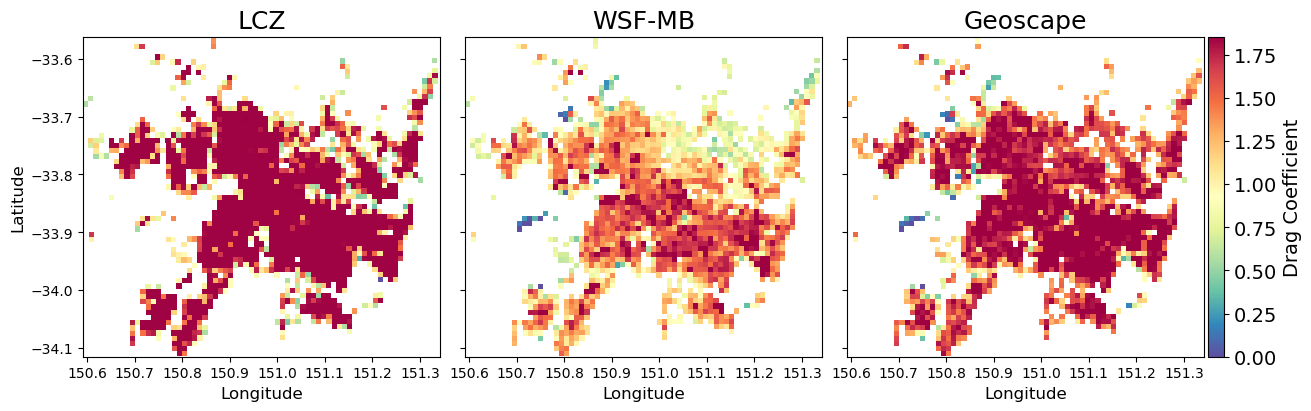

In [ ]:
# File paths and labels for drag coefficient
files = {
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/LCZ_urban_drag.nc",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/WSF3DMSB_urban_drag.nc",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/plots/Geoscape_urban_drag.nc"
}

# Variables and colorbar properties
variables = {
    "DRAG_COEFFICIENT": {
        "label": "Drag Coefficient",
        "vmin": None,
        "vmax": None,
        "cmap": "Spectral_r", #"YlGnBu",
        "extend": None#"max"
    }
}

# Get lat/lon from reference file
ref_ds = xr.open_dataset(files["LCZ"])
lat = ref_ds["XLAT"]
lon = ref_ds["XLONG"]

# Set min/max for BUILD_AREA_FRACTION using Geoscape
geo_ds = xr.open_dataset(files["Geoscape"])
geo_build_area = geo_ds["BUILD_AREA_FRACTION"]
variables["BUILD_AREA_FRACTION"]["vmin"] = float(geo_build_area.min())
variables["BUILD_AREA_FRACTION"]["vmax"] = float(geo_build_area.max())

# Set up the plot 
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(13, 4), sharex=True, sharey=True, constrained_layout=True)

for col_idx, (label, file_path) in enumerate(files.items()):
    ds = xr.open_dataset(file_path)

    # Only plot DRAG_COEFFICIENT
    varname = "DRAG_COEFFICIENT"
    props = variables[varname]
    data = ds[varname]
    ax = axs[col_idx]  # Change indexing from axs[row_idx, col_idx] to axs[col_idx]

    pcm = ax.pcolormesh(
        lon, lat, data,
        shading="auto",
        cmap=props["cmap"],
        vmin=props["vmin"],
        vmax=props["vmax"]
    )

    # Axis formatting
    if col_idx == 0:
        ax.set_ylabel("Latitude", fontsize=12)
    else:
        ax.set_ylabel('')

    ax.set_xlabel("Longitude", fontsize=12)  # Remove the row_idx == 2 condition
    ax.set_title(label, fontsize=18)  # Remove the row_idx == 0 condition

    # Colorbar only in the rightmost column
    if col_idx == 2:
        cbar = fig.colorbar(
            pcm, ax=ax, orientation="vertical", fraction=0.045, pad=0.01, extend=props["extend"]
        )
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(props["label"], fontsize=14)

plt.savefig("drag.png", dpi=300)
plt.show()